#Phase 5: Targeted Synthetic Data Augmentation

## Step 5.1: Empirically Determined Threshold (Learning Curve):

In [2]:
import matplotlib.pyplot as plt                                                                                                                           
import pandas as pd                                                                                                                                       
import os                                                                                                                                                 
import warnings                                                                                                                                           
                                                                                                                                                            
from sklearn.feature_extraction.text import TfidfVectorizer                                                                                               
from sklearn.linear_model import LogisticRegression                                                                                                       
from sklearn.metrics import f1_score                                                                                                                      
from sklearn.pipeline import make_pipeline                                                                                                                
from sklearn.utils import resample                                                                                                                        
                                                                                                                                                            
warnings.filterwarnings('ignore')           

In [3]:
base_dir = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path = os.path.join(base_dir, 'Train_Set_70.csv')
#----
base_dir1 = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path1 = os.path.join(base_dir1, 'Validation_Set_15.csv')

df_train= pd.read_csv(file_path)
df_val= pd.read_csv(file_path1)

In [4]:
# Drop nulls just in case the explosion phase left empty sentences
df_train = df_train.dropna(subset=['sentence', 'TargetAspect']).copy()                                                                                    
df_val = df_val.dropna(subset=['sentence', 'TargetAspect']).copy()   

In [5]:
df_train

,place_name,rating,shop_type,sentence,TargetAspect
0,Coffeefolks Cafe,5,coffee,If you are looking for a place that you want t...,Product Quality
1,BRGR Alley Café,5,coffee,"delicious food, great service and very nice place",Customer Service
2,BRGR Alley Café,5,coffee,"The plating was good, the drinks, the ambiance...",Ambiance and Atmosphere
3,Green Coffee - Marfori,4,coffee,"Place can cater a lot of people, they also hav...",Ambiance and Atmosphere
4,REVEL by Confex,5,coffee,"Exceptional customer service, fantastic atmosp...",Product Quality
...,...,...,...,...,...
16135,PICKUP COFFEE - Gaisano Mall of Davao,5,coffee,"They offer tea and chocolate options, in addit...",Product Quality
16136,BRGR Alley Café,1,coffee,"To be fair, I didn't experience this during my...",Customer Service
16137,Coffeecat,5,coffee,Basil pesto pasta and cheesecakes are must try...,Price and Value
16138,Green Coffee - Diversion,4,coffee,If you like to chill and drink your coffee wit...,Product Quality


In [6]:
df_val

,place_name,rating,shop_type,sentence,TargetAspect
0,Starbucks,5,coffee,All baristas are very friendly.,Customer Service
1,Kafih - Davao,1,coffee,High Speed Internet was posted infront of the ...,Facilities and Amenities
2,Floury Cafe,3,matcha,Food was average and could definitely use impr...,Product Quality
3,Green Coffee - Diversion,4,coffee,"Overall, still a great café for the ambiance, ...",Customer Service
4,Habitat Coffee - Tulip Branch,2,coffee,₱179 pesos for a really small iced seasalt latte.,Product Quality
...,...,...,...,...,...
3454,sips sala,5,matcha,Their coffee is also delicious and now I'm obs...,Product Quality
3455,Whisk It Good Matcha,5,matcha,My wife's favorite matcha place in DVO smilin...,Customer Service
3456,Starbucks - SM City Davao,5,coffee,Consistently good service.,Customer Service
3457,Daleachious Cafe - Ecoland Branch,5,coffee,"Nothing fancy of elegant about this place, but...",Product Quality


In [7]:
def map_sentiment(rating):                                                                                                                                
    if rating <= 2: return 'Negative'                                                                                                                     
    elif rating == 3: return 'Neutral'                                                                                                                    
    else: return 'Positive'                                                                                                                               
                                                                                                                                                            
df_train['Sentiment'] = df_train['rating'].apply(map_sentiment)                                                                                           
df_val['Sentiment'] = df_val['rating'].apply(map_sentiment)                                                                                               
                                                                                                                                                            
# Create the critical Aspect-Sentiment evaluation target                                                                                                  
df_train['TargetClass'] = df_train['TargetAspect'] + ' - ' + df_train['Sentiment']                                                                        
df_val['TargetClass'] = df_val['TargetAspect'] + ' - ' + df_val['Sentiment'] 

In [8]:
def plot_learning_curve(df_train, df_val, target_class, batch_sizes):                                                                                     
    f1_scores = []                                                                                                                                        
                                                                                                                                                            
    y_train_binary = (df_train['TargetClass'] == target_class).astype(int)                                                                                
    y_val_binary = (df_val['TargetClass'] == target_class).astype(int)                                                                                    
                                                                                                                                                            
    authentic_count = y_train_binary.sum()                                                                                                                
    print(f"Total authentic training instances for '{target_class}': {authentic_count}")                                                                  
                                                                                                                                                            
    proxy_model = make_pipeline(                                                                                                                          
        TfidfVectorizer(max_features=5000, ngram_range=(1,2)),                                                                                            
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                                                                       
    )                                                                                                                                                     
                                                                                                                                                            
    valid_batch_sizes = [size for size in batch_sizes if size <= len(df_train)]                                                                           
                                                                                                                                                            
    for size in valid_batch_sizes:                                                                                                                        
        df_subset = resample(df_train, n_samples=size, replace=False, stratify=y_train_binary, random_state=42)                                           
                                                                                                                                                            
        X_subset = df_subset['sentence'].fillna('')                                                                                                       
        y_subset = (df_subset['TargetClass'] == target_class).astype(int)                                                                                 
                                                                                                                                                            
        proxy_model.fit(X_subset, y_subset)                                                                                                               
        y_pred = proxy_model.predict(df_val['sentence'].fillna(''))                                                                                       
                                                                                                                                                            
        score = f1_score(y_val_binary, y_pred, zero_division=0)                                                                                           
        f1_scores.append(score)                                                                                                                           
                                                                                                                                                            
    plt.figure(figsize=(9, 5))                                                                                                                            
    plt.plot(valid_batch_sizes, f1_scores, marker='o', linestyle='-', color='b')                                                                          
    plt.title(f'Learning Curve: {target_class}')                                                                                                          
    plt.xlabel('Number of Total Training Instances Processed')                                                                                            
    plt.ylabel('F1 Score')                                                                                                                                
    plt.grid(True)                                                                                                                                        
    plt.show()      

Total authentic training instances for 'Product Quality - Negative': 836


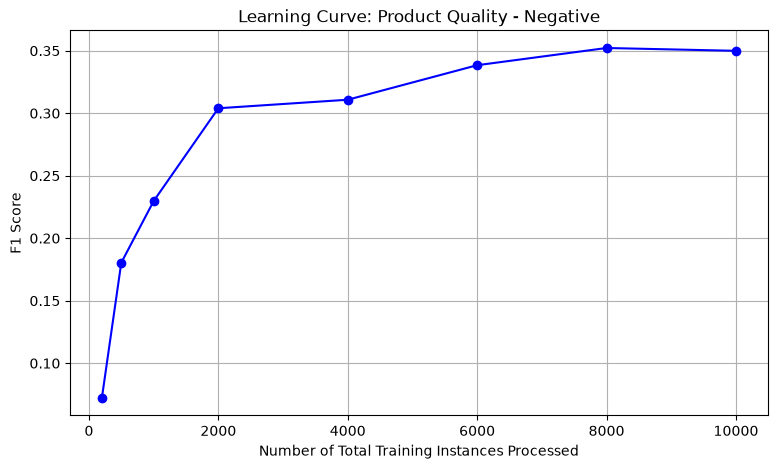

Total authentic training instances for 'Customer Service - Negative': 616


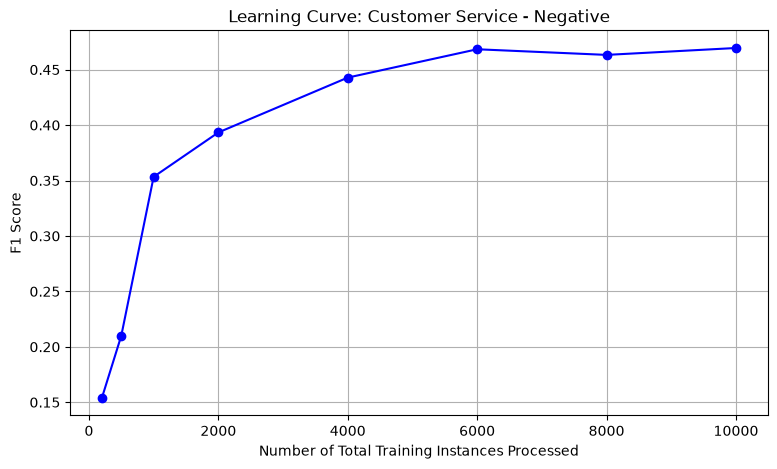

Total authentic training instances for 'Ambiance and Atmosphere - Negative': 112


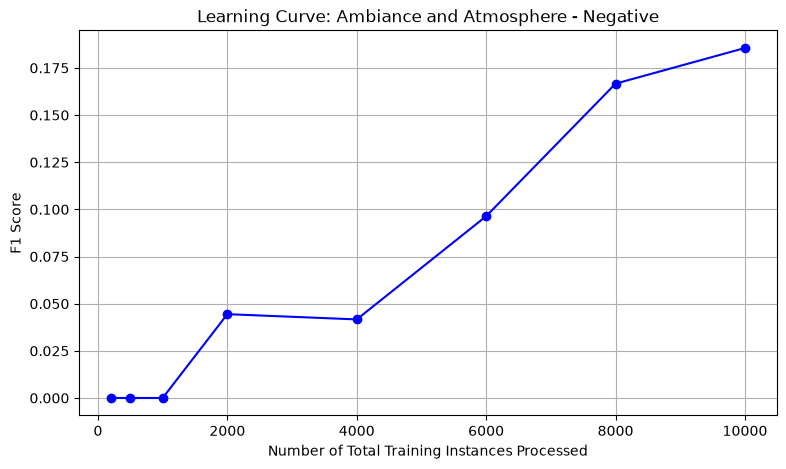

Total authentic training instances for 'Store Operations and Accessibility - Negative': 113


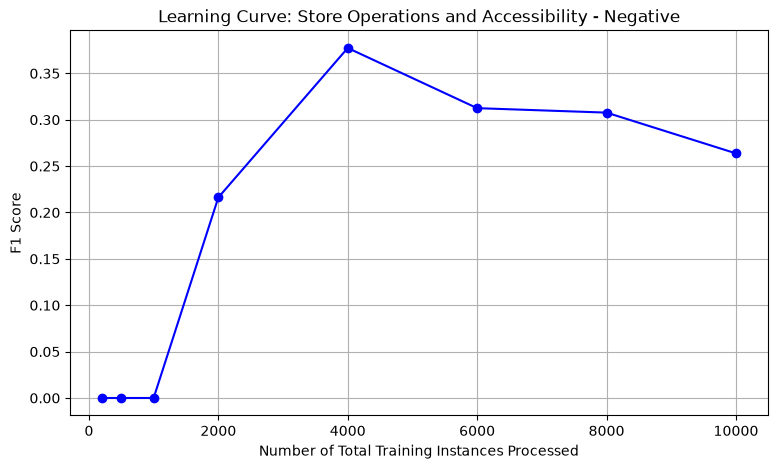

Total authentic training instances for 'Price and Value - Negative': 124


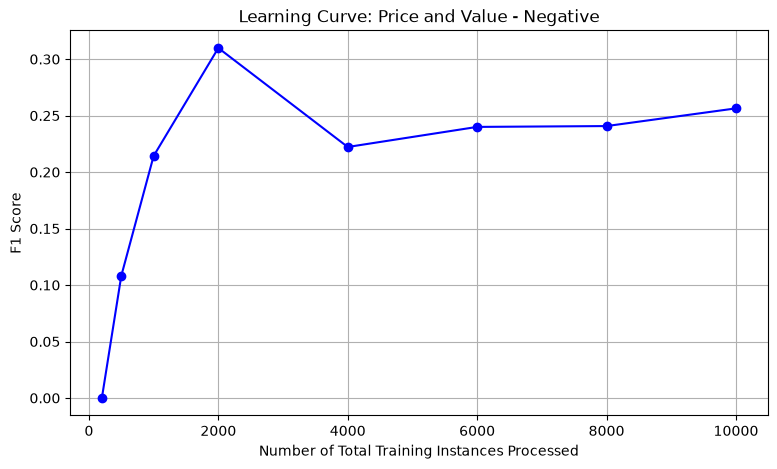

Total authentic training instances for 'Facilities and Amenities - Negative': 157


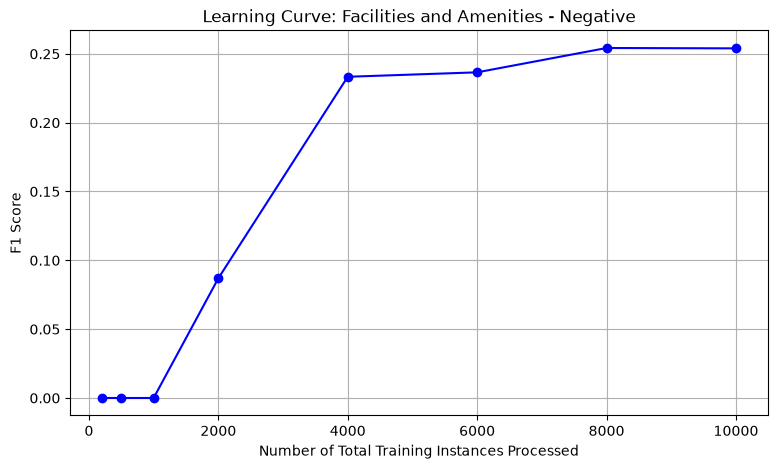

In [9]:
batch_sizes = [200, 500, 1000, 2000, 4000, 6000, 8000, 10000]                                                                                            

plot_learning_curve(df_train, df_val, 'Product Quality - Negative', batch_sizes)
plot_learning_curve(df_train, df_val, 'Customer Service - Negative', batch_sizes)             
plot_learning_curve(df_train, df_val, 'Ambiance and Atmosphere - Negative', batch_sizes)                                                                      
plot_learning_curve(df_train, df_val, 'Store Operations and Accessibility - Negative', batch_sizes)                                                       
plot_learning_curve(df_train, df_val, 'Price and Value - Negative', batch_sizes)                                                                          
plot_learning_curve(df_train, df_val, 'Facilities and Amenities - Negative', batch_sizes)  

In [10]:
total_counts = df_train['TargetAspect'].value_counts()                                                                                                   
                                                                                                                                                            
print("Total Authentic Instances per Aspect in Train Set:")                                                                                              
print(total_counts)   

Total Authentic Instances per Aspect in Train Set:
TargetAspect
Product Quality                       7727
Customer Service                      3228
Ambiance and Atmosphere               2159
Facilities and Amenities              1344
Store Operations and Accessibility     846
Price and Value                        836
Name: count, dtype: int64


In [11]:
batch_sizes = [150, 300, 500, 750, 1000, 1250, 1500, 1750, 2000] 

def plot_learning_curve(df_train, df_val, target_aspect, batch_sizes):                               
    target_aspect = target_aspect.strip()                                                            
    f1_scores = []                                                                                   
                                                                                                        
    y_train_binary = (df_train['TargetAspect'] == target_aspect).astype(int)                         
    y_val_binary = (df_val['TargetAspect'] == target_aspect).astype(int)                             
                                                                                                        
    proxy_model = make_pipeline(                                                                     
        TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),                                      
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                  
    )                                                                                                
                                                                                                        
    for size in batch_sizes:                                                                         
        df_subset = resample(                                                                        
            df_train,                                                                                
            n_samples=size,                                                                          
            replace=False,                                                                           
            stratify=y_train_binary,                                                                 
            random_state=42                                                                          
        )                                                                                            
                                                                                                        
        X_subset = df_subset['sentence'].fillna('')                                                  
        y_subset = (df_subset['TargetAspect'] == target_aspect).astype(int)                          
                                                                                                        
        proxy_model.fit(X_subset, y_subset)                                                          
        y_pred = proxy_model.predict(df_val['sentence'].fillna(''))                                  
                                                                                                        
        score = f1_score(y_val_binary, y_pred, zero_division=0)                                      
        f1_scores.append(score)                                                                      
                                                                                                        
    plt.figure(figsize=(8, 4.5))                                                                     
    plt.plot(batch_sizes, f1_scores, marker='o', linestyle='-', color='b')                           
    plt.title(f'Learning Curve: {target_aspect}')                                                    
    plt.xlabel('Number of Authentic Training Instances')                                             
    plt.ylabel('F1 Score')                                                                           
    plt.ylim(0, 1.0)                                                                                 
    plt.grid(True)                                                                                   
    plt.show()     

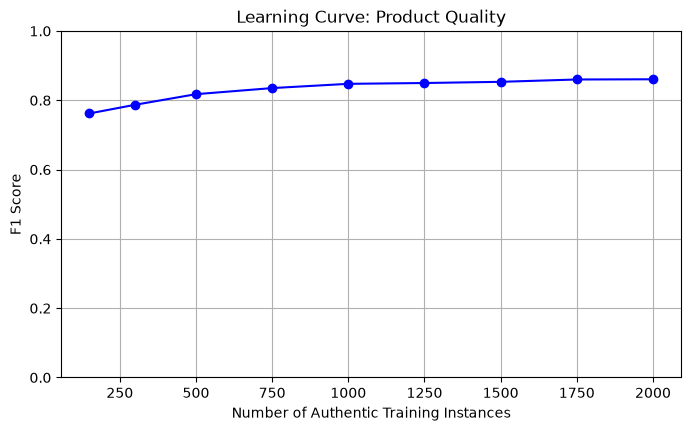

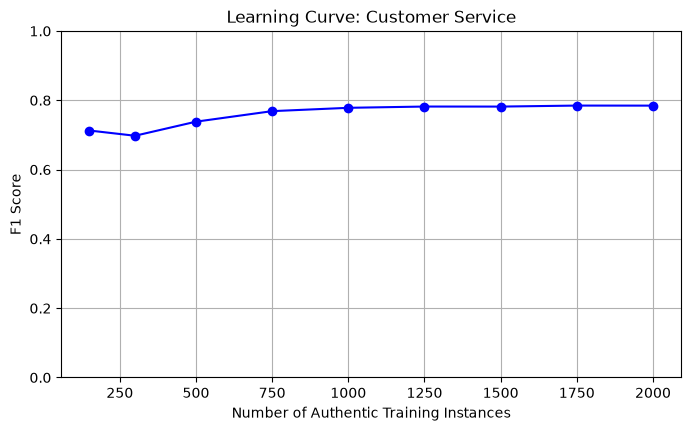

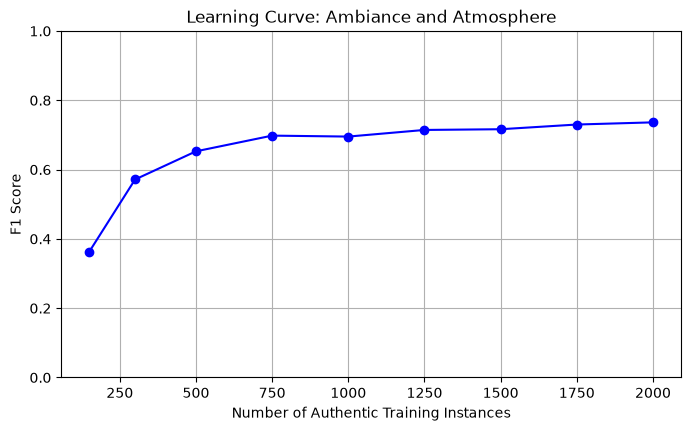

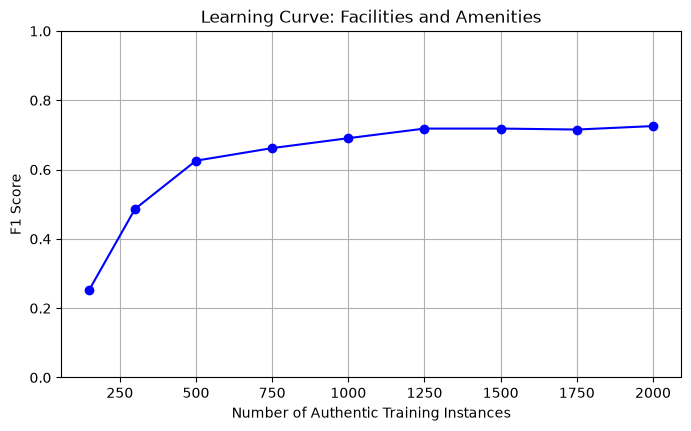

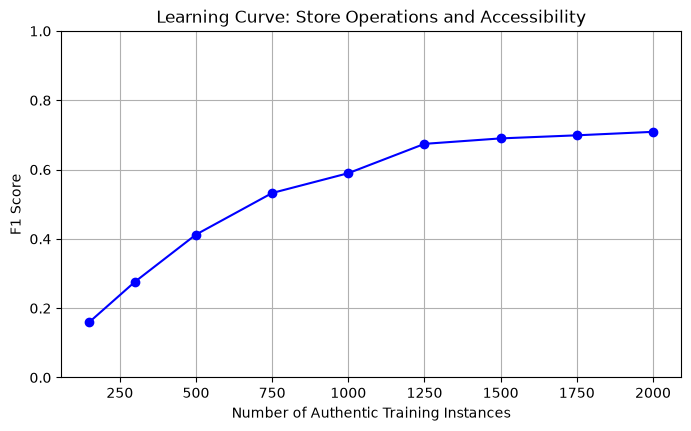

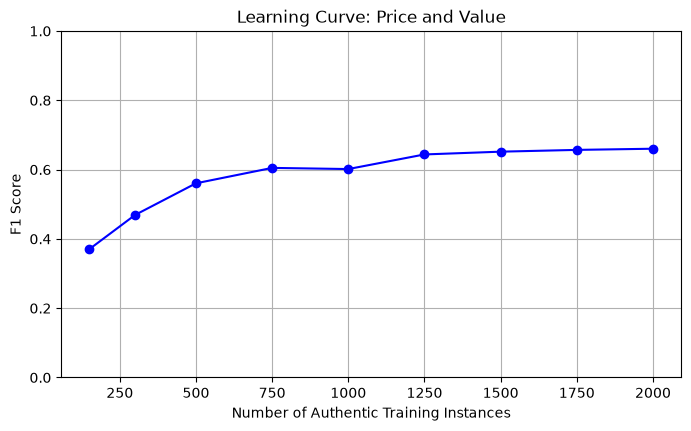

In [12]:
plot_learning_curve(df_train, df_val, 'Product Quality', batch_sizes)                                
                                                                                                        
plot_learning_curve(df_train, df_val, 'Customer Service', batch_sizes)                               
                                                                                                        
plot_learning_curve(df_train, df_val, 'Ambiance and Atmosphere', batch_sizes)                        
                                                                                                        
plot_learning_curve(df_train, df_val, 'Facilities and Amenities', batch_sizes)                       
                                                                                                        
plot_learning_curve(df_train, df_val, 'Store Operations and Accessibility', batch_sizes)             
                                                                                                        
plot_learning_curve(df_train, df_val, 'Price and Value', batch_sizes)                                


In [13]:
# Check the exact counts of authentic negative (1-star and 2-star) reviews for these categories in the Train_Set_70.csv
negative_reviews = df_train[df_train['rating'] <= 2]                                                                                                                                                                                                            
negative_counts = negative_reviews.groupby('TargetAspect').size()                                                                                                                                                                                                                                              
print("Authentic Negative Instances (1-star & 2-star) in Train Set:")                                                                                    
print(negative_counts)       

Authentic Negative Instances (1-star & 2-star) in Train Set:
TargetAspect
Ambiance and Atmosphere               112
Customer Service                      616
Facilities and Amenities              157
Price and Value                       124
Product Quality                       836
Store Operations and Accessibility    113
dtype: int64


Threshold for synthetic data: 250

The True Plateau: The Phase 5.1 learning curve for Customer Service - Negative flatlines at 6,000 total subsampled instances. Because negative reviews only make up ~3.8% of the corpus, that 6,000-row checkpoint contains approximately 230 authentic negative reviews. Ingesting data beyond this point yielded zero F1-score improvement. Rounding to 250 provides a clean, mathematically sound ceiling based directly on the actual inflection point.


Preventing Model Collapse: The framework explicitly dictates that synthetic data must function strictly as a regulated fallback safety net to prevent the severe loss of linguistic diversity identified by Guo et al. Using the previous 616 target forces the generation of ~500 synthetic rows per class, making the minority categories over 80% AI-generated. Capping the target threshold at 250 ensures the XLM-RoBERTa model hits its learning plateau while maintaining authentic human Bislish/Taglish text as the majority training signal.


| Target Aspect | Authentic Rows | Synthetic Rows Needed | Final Total | Synthetic Ratio |
| :--- | :--- | :--- | :--- | :--- |
| Ambiance | 112 | 138 | 250 | 55.2% |
| Store Operations | 113 | 137 | 250 | 54.8% |
| Price & Value | 124 | 126 | 250 | 50.4% |
| Facilities | 157 | 93 | 250 | 37.2% |


The learning curve for **Customer Service - Negative** flattens out entirely at the **6,000-instance mark**. Adding another 4,000 rows (up to the 10,000 mark) produces zero improvement in the F1 score, which defines the minimum viable threshold. However, that 6,000 number represents a random subsample of the entire mixed dataset, which is overwhelmingly positive. 

### The Prevalence Calculation
The target class is a severe minority. Out of the **16,140 total rows** in the training set, only **616** belong to Customer Service - Negative.

$$\text{Class Prevalence: } \frac{616}{16,140} = 3.81\%$$

### Extracting the True Threshold
Because the training subset was drawn randomly to create the learning curve, the model was only exposed to that 3.81% prevalence rate at every plotted interval. At the 6,000-row plateau point, this equates to **228.6 actual negative instances** ($6,000 \times 0.0381$). 

The team rounded approximately 229 up to a clean **250** to provide a slight mathematical buffer. Generating synthetic data beyond this 250-row target forces the model to overfit on LLM outputs, causing the exact loss of linguistic diversity the established methodology explicitly tries to prevent.


In [14]:
# Extract authentic negative seed examples (rating <= 2)
target_classes = [
    'Store Operations and Accessibility', 
    'Price and Value', 
    'Facilities and Amenities',
    'Ambiance and Atmosphere'
]


for aspect in target_classes:
    print(f"\n--- Seeds for {aspect} ---")
    subset = df_train[(df_train['TargetAspect'] == aspect) & (df_train['rating'] <= 2)]
    seeds = subset['sentence'].dropna().sample(min(5, len(subset)), random_state=42).tolist()
    
    for i, seed in enumerate(seeds, 1):
        print(f"{i}. {seed}")


--- Seeds for Store Operations and Accessibility ---
1. I called ahead and was told they close at 4 PM.
2. far from sleep close to diabetes
3. HEADS UP: nearly there for 4 hours and when I left my clothes smelled bad.
4. Even two hours later, both my wife and I were still experiencing the effects of the fumes, which included lightheadedness and respiratory irritation.
5. Comparing to places like steep or &matcha, where prices are around 250-320, sobrang layo ng quality (although may mas mahal na options sa davao, sobrang layo ng quality compared to here) So if you want to get out davao city and be in a nice place, you can go here.

--- Seeds for Price and Value ---
1. While the food quality showed some improvement, the serving size remained relatively small for its value.
2. Unfortunately, the drink feels overpriced for what it delivers.
3. Food is expensive too.
4. Expensive but the food is tasteless
5. The price.. Pricey sya for a Davao food standpoint.

--- Seeds for Facilities and

You are an expert NLP data annotator. Generate 50 realistic, negative customer reviews (1-star or 2-star complaints) for coffee and matcha shops in Davao City.

Constraints:

Target Aspect: [Insert Target Aspect, e.g., 'Ambiance and Atmosphere']

Dialect: Authentic Davao Bislish / Taglish (informal conversational mix of Bisaya, Tagalog, and English). Do not use deep formal Tagalog.

Length: 5 to 30 words maximum.

Authentic Examples (Match this tone strictly):

[Insert Seed 1]

[Insert Seed 2]

[Insert Seed 3]

[Insert Seed 4]

[Insert Seed 5]

Output Format:
Return ONLY a raw CSV block with a header. Do not write any conversational text before or after the code block.
Columns: place_name,rating,shop_type,sentence,TargetAspect,Sentiment,TargetClass,is_synthetic
Example row: "Synthetic Cafe",1,"coffee","Kusog kaayo tung kanta sakit sa dunggan","Ambiance and Atmosphere","Negative","Ambiance and Atmosphere - Negative",True

#Exp